In [ ]:
# Install missing data visualization library
!pip install missingno

# Import essential libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import missingno as msno
import ssl
import certifi
from sklearn.datasets import fetch_openml
%matplotlib inline

# Configure SSL for secure downloads
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving MiamiHousing.csv to MiamiHousing.csv


In [ ]:
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Load the dataset
df_X = pd.read_csv(filename)
print(f"Dataset loaded successfully with shape: {df_X.shape}")

Uploaded file: MiamiHousing.csv
Dataset loaded successfully with shape: (13932, 17)


In [ ]:
# Display basic information about your dataset
print(f"Dataset shape: {df_X.shape}")
print(f"Dataset type: {type(df_X)}")

# Show random samples to understand data format
display(df_X.sample(5))

# Get detailed information about columns and data types
df_X.info()

# Count occurrences of each data type
print("Data type distribution:")
print(pd.value_counts(df_X.dtypes))

Dataset shape: (13932, 17)
Dataset type: <class 'pandas.core.frame.DataFrame'>


,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
10529,25.491879,-80.422337,3079100040060,208000.0,6000,1735,2138,20428.5,27014.7,17371.4,128162.9,79902.8,579.8,18,0,8,2
9327,25.591985,-80.343368,3660040170140,370000.0,11500,2767,29203,13028.4,11440.9,1580.3,83404.4,36351.7,8110.5,48,0,5,4
11010,25.937557,-80.336641,3020100140210,369000.0,8197,1968,28871,22123.2,71012.8,371.8,75186.5,72940.0,4505.9,10,0,2,4
5567,25.641488,-80.370530,3050190170200,545000.0,23881,2606,53371,5692.0,23232.8,18272.8,76335.0,25292.6,4782.0,36,0,9,4
3194,25.749743,-80.298939,3040120070740,523000.0,7500,2504,10800,2860.3,20916.3,4218.4,36275.8,13232.7,6862.6,0,0,7,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13932 entries, 0 to 13931
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LATITUDE           13932 non-null  float64
 1   LONGITUDE          13932 non-null  float64
 2   PARCELNO           13932 non-null  int64  
 3   SALE_PRC           13932 non-null  float64
 4   LND_SQFOOT         13932 non-null  int64  
 5   TOT_LVG_AREA       13932 non-null  int64  
 6   SPEC_FEAT_VAL      13932 non-null  int64  
 7   RAIL_DIST          13932 non-null  float64
 8   OCEAN_DIST         13932 non-null  float64
 9   WATER_DIST         13932 non-null  float64
 10  CNTR_DIST          13932 non-null  float64
 11  SUBCNTR_DI         13932 non-null  float64
 12  HWY_DIST           13932 non-null  float64
 13  age                13932 non-null  int64  
 14  avno60plus         13932 non-null  int64  
 15  month_sold         13932 non-null  int64  
 16  structure_quality  139

/tmp/ipython-input-1865375405.py:13: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(df_X.dtypes))


/tmp/ipython-input-1492547985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x=unique_values.index, y=unique_values, palette='inferno')
/tmp/ipython-input-1492547985.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')


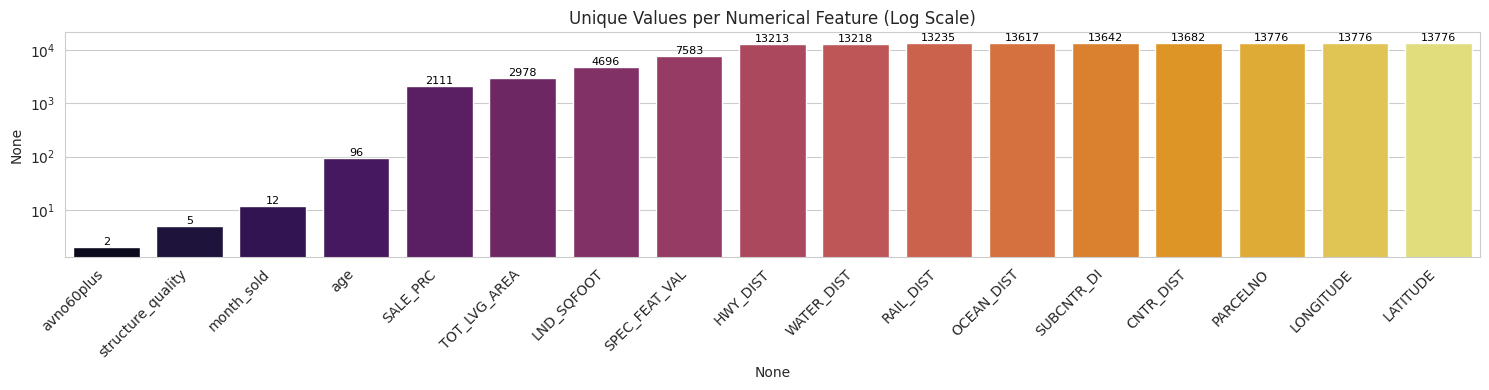

In [ ]:
# Analyze unique values in numerical features
unique_values = df_X.select_dtypes(include='number').nunique().sort_values()

# Create visualization of unique value distribution
plt.figure(figsize=(15, 4))
sns.set_style('whitegrid')
g = sns.barplot(x=unique_values.index, y=unique_values, palette='inferno')
g.set_yscale("log")
g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
g.set_title('Unique Values per Numerical Feature (Log Scale)')

# Add value labels to bars
for index, value in enumerate(unique_values):
    g.text(index, value, str(value), color='black', ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Check for duplicate records (excluding index columns if present)
index_cols = [col for col in df_X.columns if 'index' in col.lower() or 'id' in col.lower()]
analysis_cols = [col for col in df_X.columns if col not in index_cols]

n_duplicates = df_X[analysis_cols].duplicated().sum()
print(f"Number of duplicate records: {n_duplicates}")
print(f"Percentage of duplicates: {(n_duplicates/len(df_X))*100:.2f}%")

# Remove duplicates if found
if n_duplicates > 0:
    df_X.drop_duplicates(subset=analysis_cols, inplace=True)
    print(f"Dataset shape after removing duplicates: {df_X.shape}")

Number of duplicate records: 0
Percentage of duplicates: 0.00%


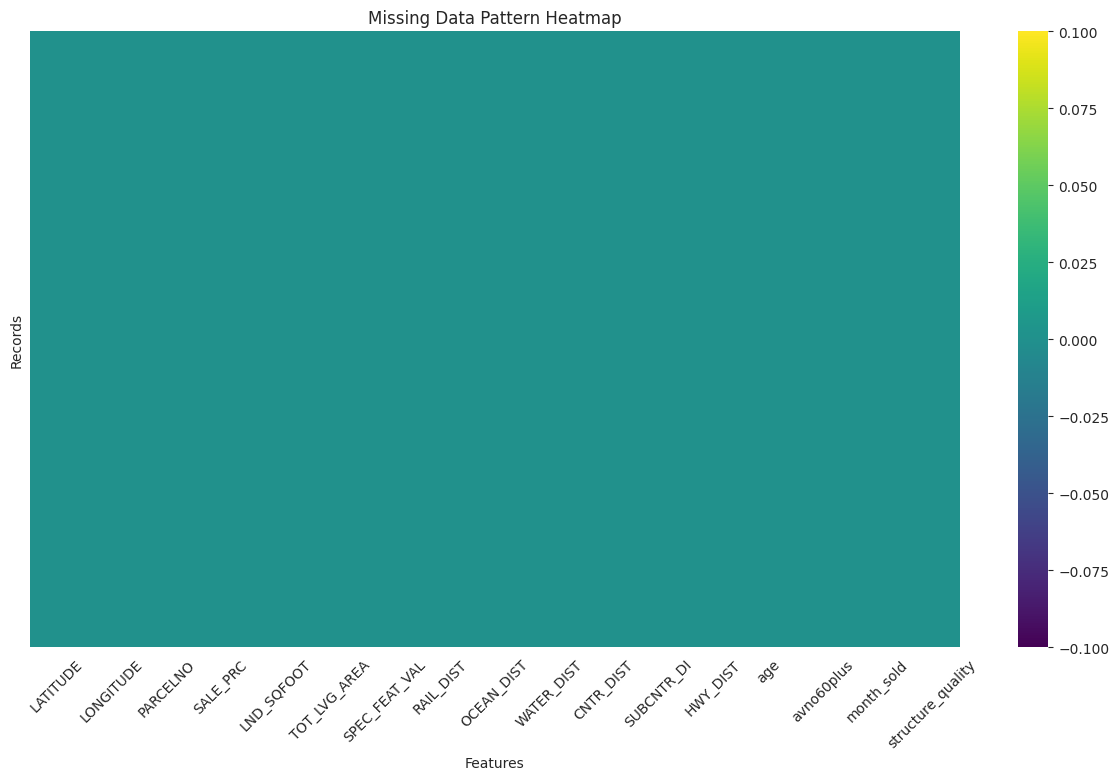

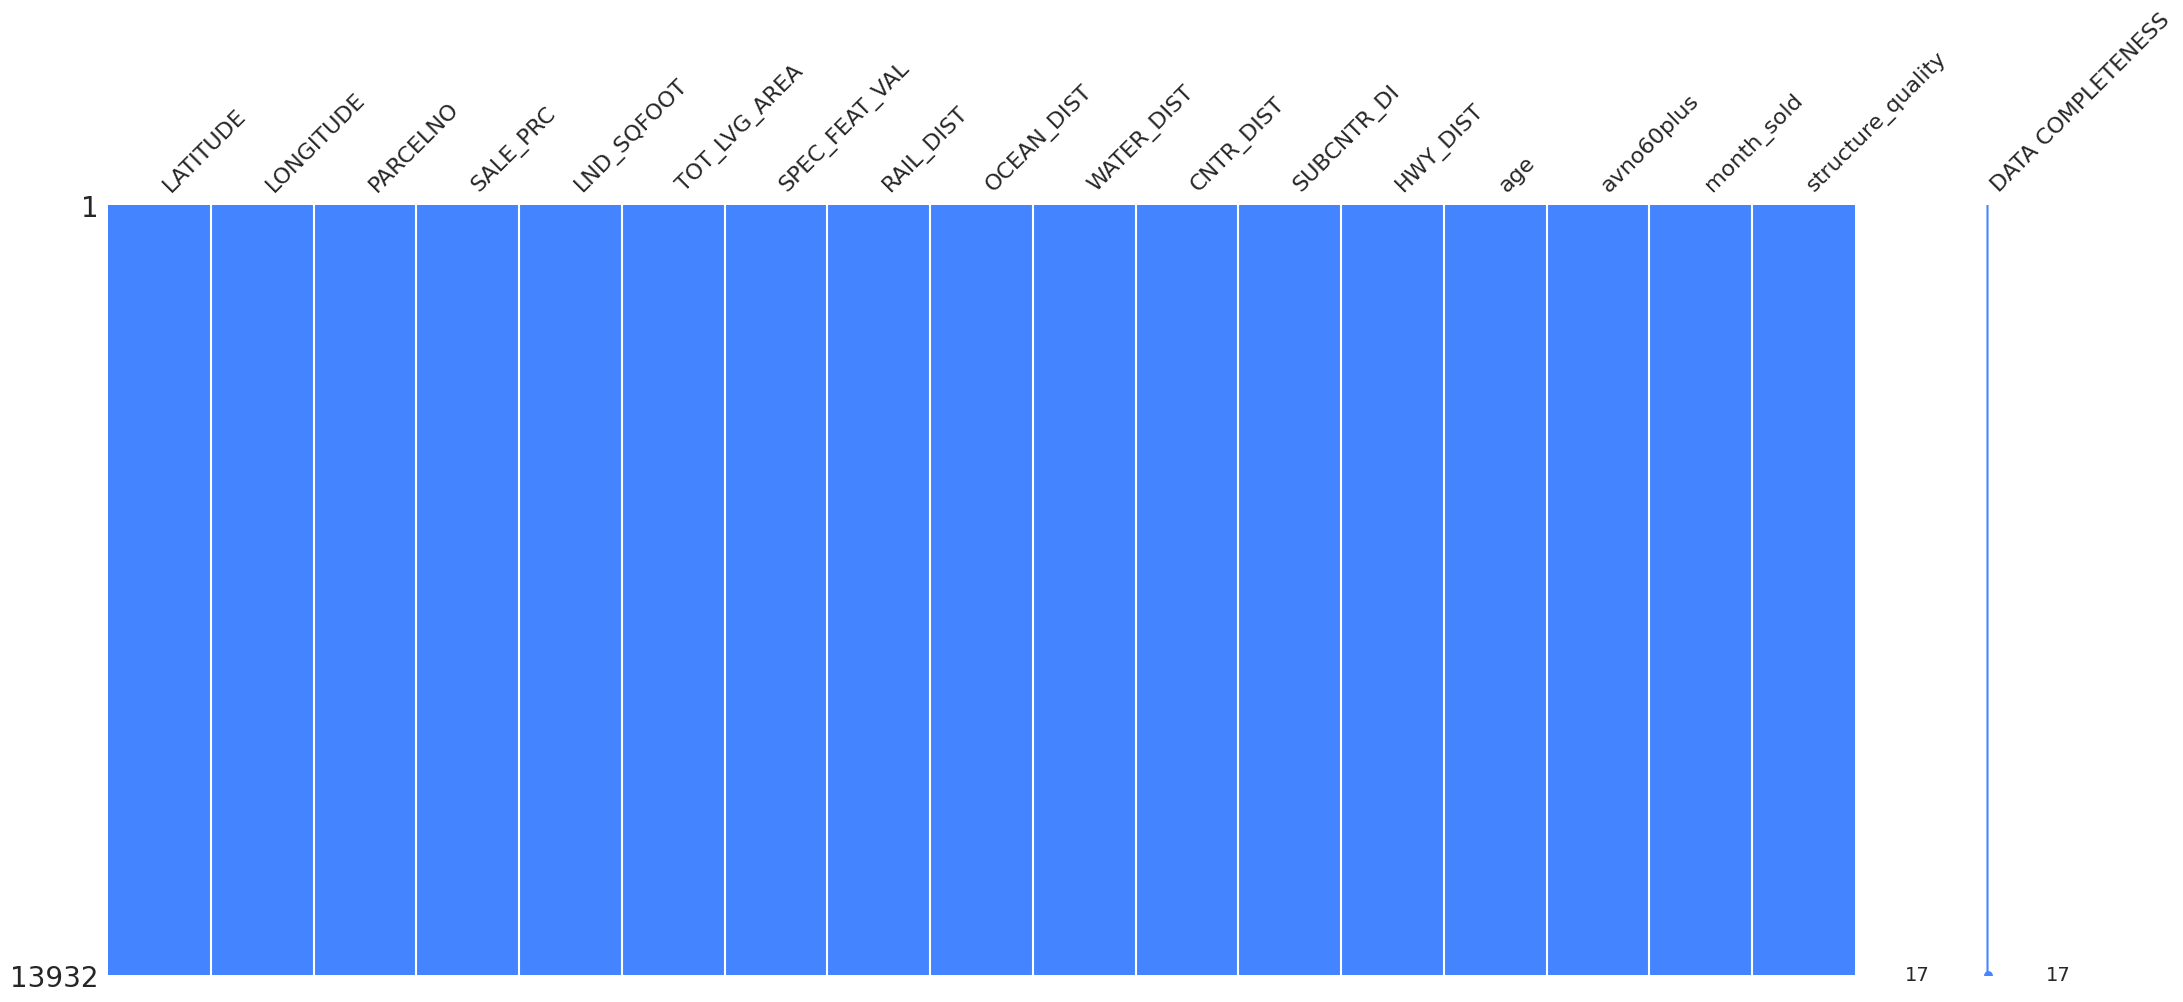

In [ ]:
# Create missing data heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df_X.isnull(), cbar=True, cmap='viridis',
            yticklabels=False, xticklabels=True)
plt.title('Missing Data Pattern Heatmap')
plt.xlabel('Features')
plt.ylabel('Records')
plt.xticks(rotation=45)
plt.show()

# Use missingno for advanced missing data visualization
msno.matrix(df_X, labels=True, sort='descending', color=(0.27, 0.52, 1.0))
plt.show()

In [ ]:
# Calculate the percentage of missing values for each column
missing_data = df_X.isnull().sum() / len(df_X) * 100

# Display the missing data summary
print("Percentage of missing data per column:")
print(missing_data.sort_values(ascending=False))

Percentage of missing data per column:
LATITUDE             0.0
LONGITUDE            0.0
PARCELNO             0.0
SALE_PRC             0.0
LND_SQFOOT           0.0
TOT_LVG_AREA         0.0
SPEC_FEAT_VAL        0.0
RAIL_DIST            0.0
OCEAN_DIST           0.0
WATER_DIST           0.0
CNTR_DIST            0.0
SUBCNTR_DI           0.0
HWY_DIST             0.0
age                  0.0
avno60plus           0.0
month_sold           0.0
structure_quality    0.0
dtype: float64


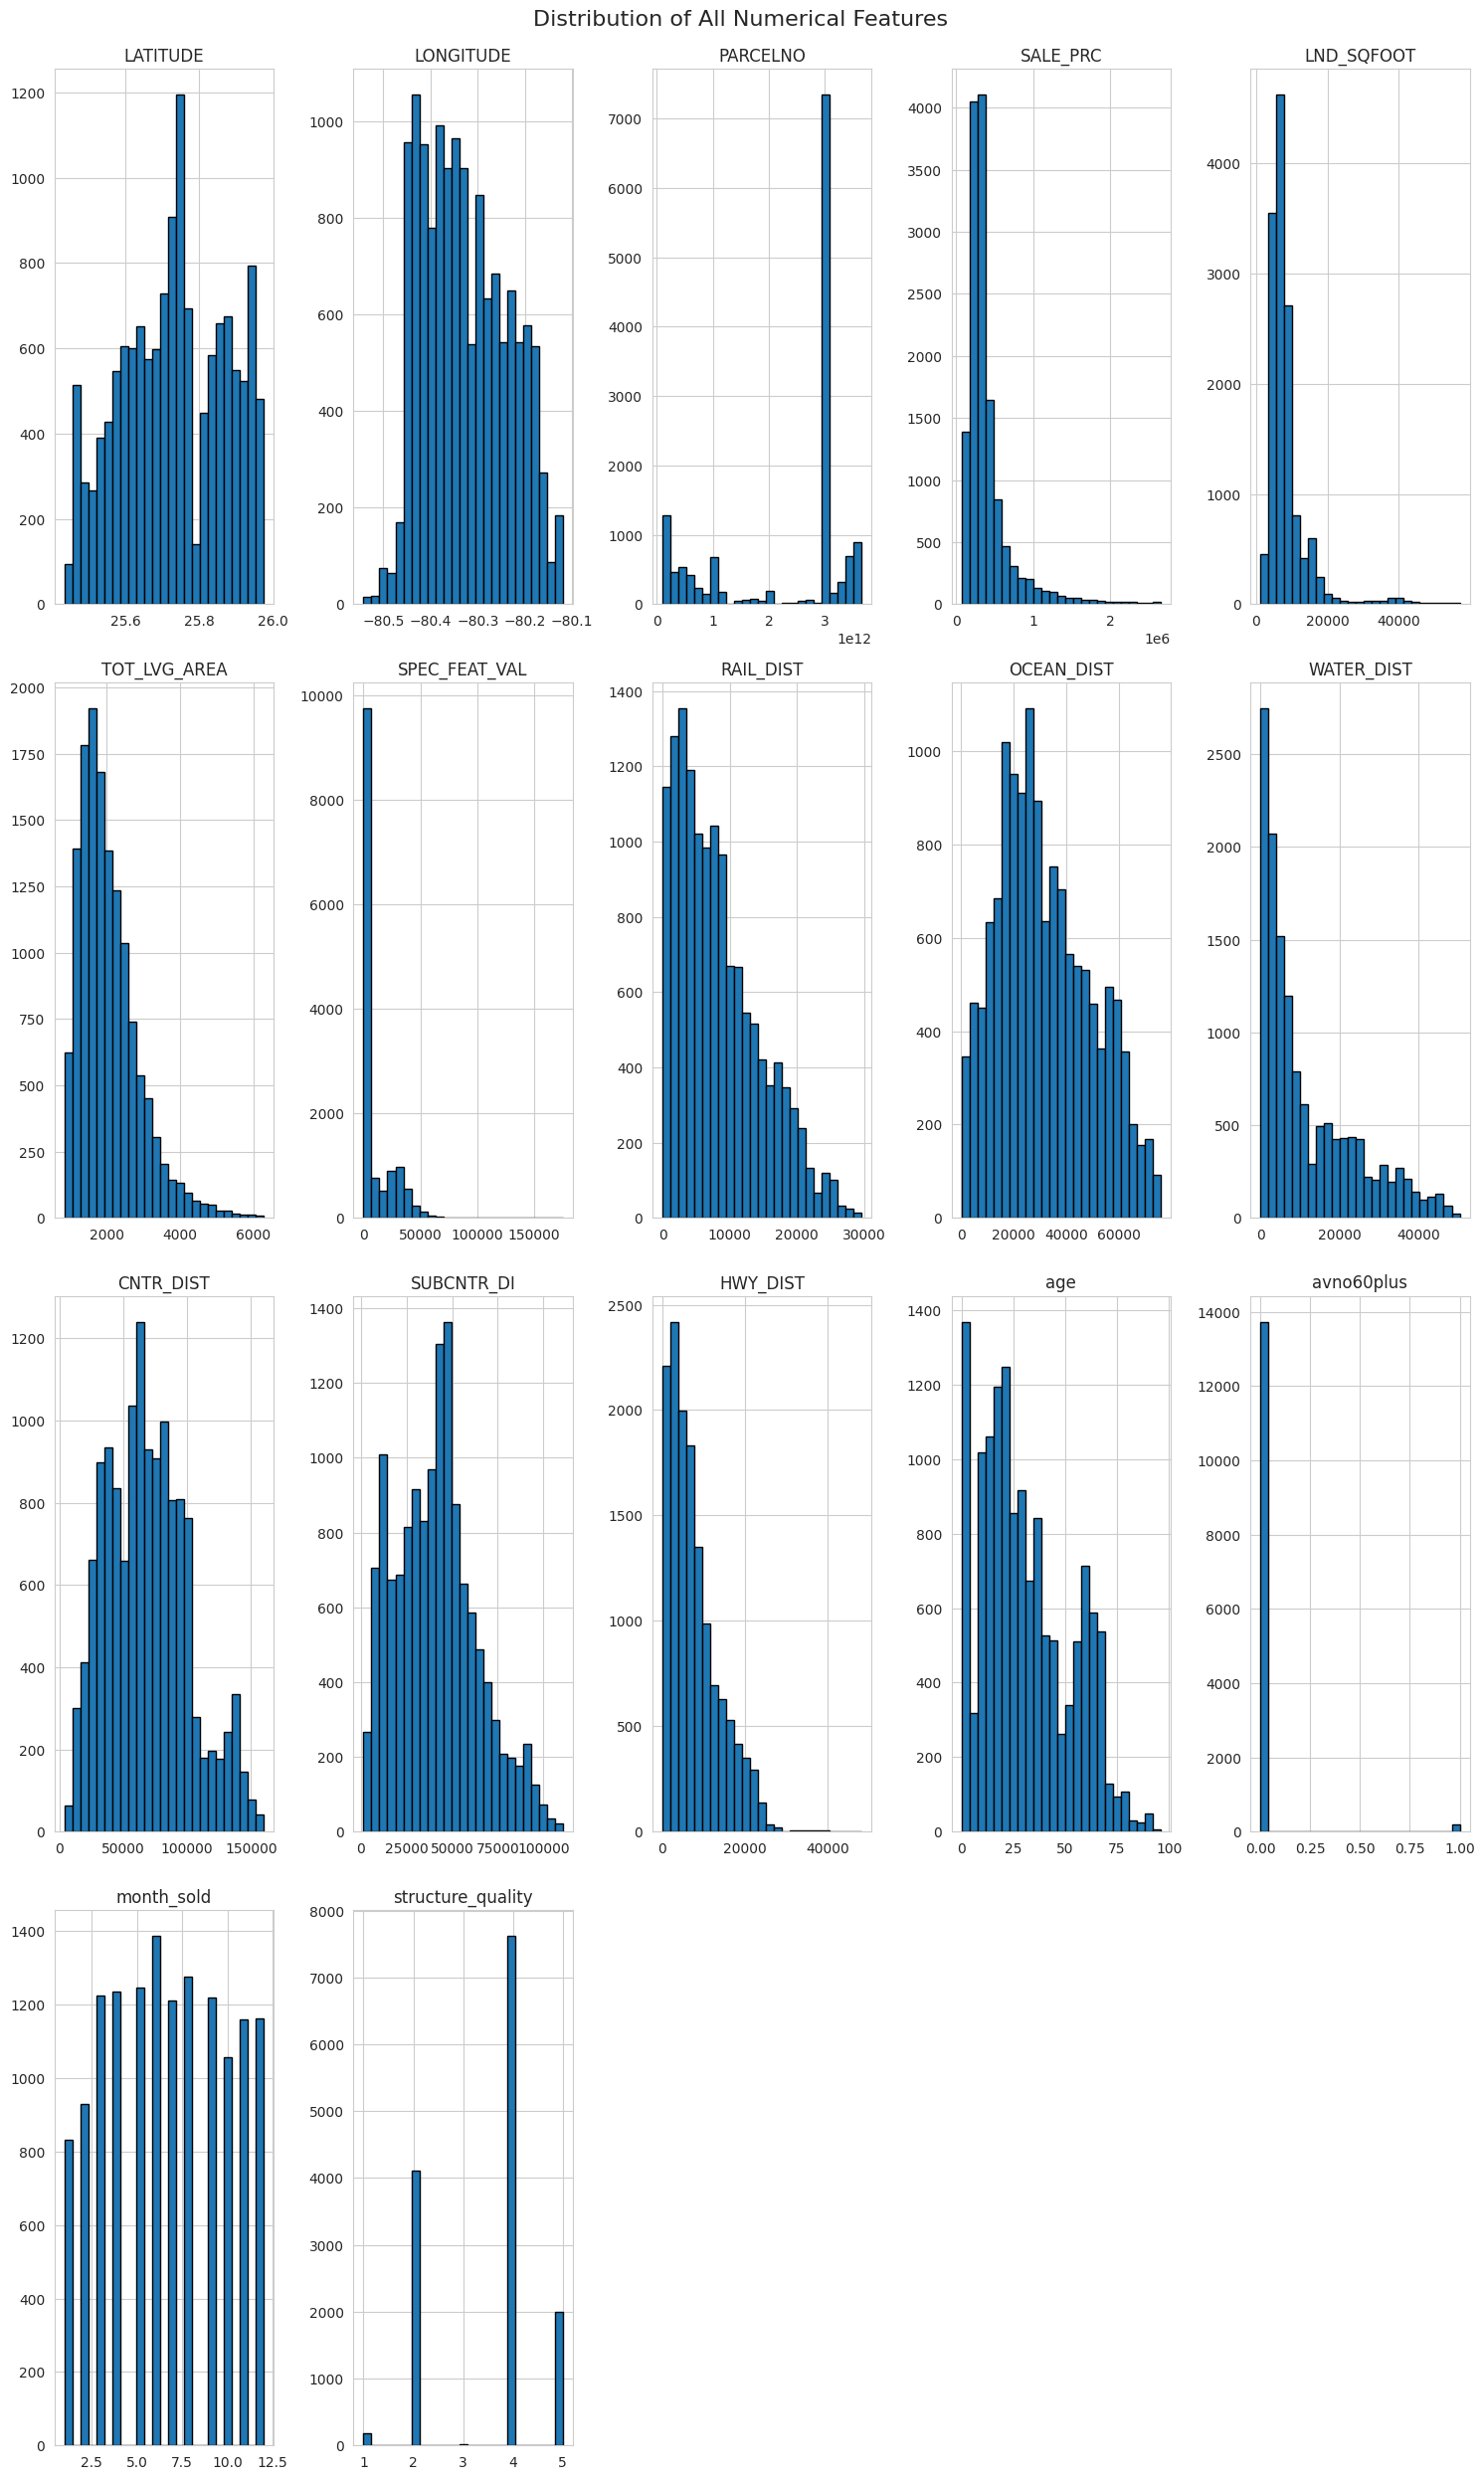

Top 5 features with highest single-value dominance:


,0
avno60plus,0.985070
structure_quality,0.547301
SPEC_FEAT_VAL,0.164370
month_sold,0.099555
LND_SQFOOT,0.073285


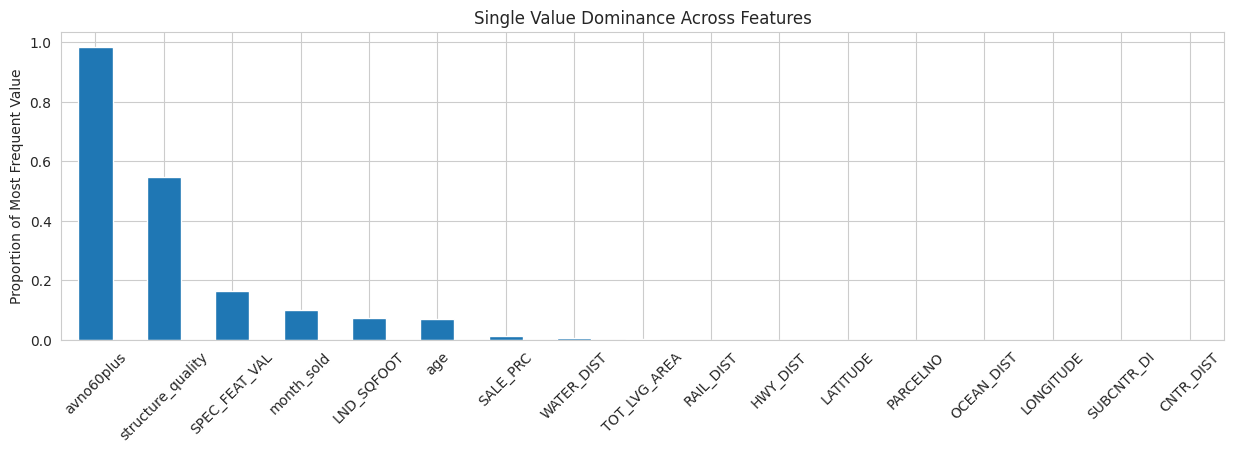

In [ ]:
# Create histograms for all numerical features
df_X.hist(bins=25, figsize=(15, 25), layout=(-1, 5), edgecolor="black")
plt.suptitle('Distribution of All Numerical Features', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

# Identify features dominated by single values
most_frequent_entry = df_X.mode()
df_freq = df_X.eq(most_frequent_entry.iloc[0].values, axis=1)
df_freq = df_freq.mean().sort_values(ascending=False)

print("Top 5 features with highest single-value dominance:")
display(df_freq.head())

# Visualize single-value dominance
df_freq.plot.bar(figsize=(15, 4),
                title="Single Value Dominance Across Features",
                ylabel="Proportion of Most Frequent Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Analyze discrete features
# Identify continuous columns
continuous_cols = df_X.select_dtypes(include=np.number).columns
df_continuous = df_X[continuous_cols]

# Identify discrete columns (assuming numerical columns not identified as continuous are discrete)
discrete_cols = [col for col in df_X.columns if col not in continuous_cols]
df_discrete = df_X[discrete_cols]


if len(df_discrete.columns) > 0:
    # Create strip plots for discrete features against a continuous target
    if len(continuous_cols) > 0:
        target_col = continuous_cols[0]  # Use first continuous column as target

        # Setup subplot grid
        n_cols = 3
        n_elements = min(len(df_discrete.columns), 9)  # Limit to 9 plots
        n_rows = np.ceil(n_elements / n_cols).astype("int")

        fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows,
                               figsize=(15, n_rows * 3))

        # Create plots for each discrete feature
        for i, col in enumerate(df_discrete.columns[:n_elements]):
            row = i // n_cols
            col_idx = i % n_cols
            ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

            try:
                sns.stripplot(data=df_X, x=col, y=target_col,
                            ax=ax, palette="Set2", size=2, alpha=0.6)
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            except:
                ax.text(0.5, 0.5, f'Cannot plot\n{col}',
                       transform=ax.transAxes, ha='center')

        plt.suptitle(f'Discrete Features vs {target_col}', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("No continuous columns found to use as target.")
else:
    print("No discrete columns found in the dataset.")

No discrete columns found in the dataset.


In [ ]:
# Generate summary statistics report
print("=== EXPLORATORY DATA ANALYSIS SUMMARY ===")
print(f"Dataset Dimensions: {df_X.shape[0]:,} rows × {df_X.shape[1]} columns")
print(f"Memory Usage: {df_X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Numerical Features: {len(df_X.select_dtypes(include='number').columns)}")
print(f"Categorical Features: {len(df_X.select_dtypes(exclude='number').columns)}")
print(f"Missing Values: {df_X.isnull().sum().sum():,} total")
print(f"Complete Records: {len(df_X.dropna()):,} ({len(df_X.dropna())/len(df_X)*100:.1f}%)")



=== EXPLORATORY DATA ANALYSIS SUMMARY ===
Dataset Dimensions: 13,932 rows × 17 columns
Memory Usage: 1.81 MB
Numerical Features: 17
Categorical Features: 0
Missing Values: 0 total
Complete Records: 13,932 (100.0%)


In [ ]:
import requests
import json
import pandas as pd

# 1. Configuration
# IMPORTANT: Replace the placeholder with your actual BLS API key
BLS_KEY = "f2d659018ccf432b95634a8315e52e21"
DATA_URL = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'
HEADERS = {'Content-type': 'application/json'}

# 2. Define the Request Body - FOCUSED ON 2016
DATA_REQUEST = json.dumps({
    # Unemployment Rate (National, Not Seasonally Adjusted) and CPI for Shelter
    "seriesid": ["LNS14000000", "CUURS49BSA0"],
    "startyear": "2016", # <-- Only need 2016
    "endyear": "2016",   # <-- Only need 2016
    "registrationkey": BLS_KEY
})

# 3. Make the POST Request and Process
try:
    print(f"Attempting to fetch 2016 data from the BLS API...")

    response = requests.post(DATA_URL, data=DATA_REQUEST, headers=HEADERS, timeout=30)
    response.raise_for_status()

    json_data = response.json()

    # Check for BLS-specific errors (e.g., bad key or series ID)
    if json_data['status'] == 'REQUEST_NOT_PROCESSED':
        print(f"❌ BLS Data Error: {json_data['message'][0]}")
        raise ValueError("BLS API request failed.")

    # Process the time-series data into a list of dictionaries
    all_data = []

    for series in json_data['Results']['series']:
        series_id = series['seriesID']
        for item in series['data']:
            all_data.append({
                'Series_ID': series_id,
                'Year': item['year'],
                'Period': item['periodName'],
                'Value': item['value']
            })

    df_bls_2016 = pd.DataFrame(all_data)

    print("\n✅ BLS 2016 Data Loaded Successfully!")
    print(df_bls_2016)

except requests.exceptions.RequestException as e:
    print(f"\n❌ A connection or HTTP error occurred: {e}")
except Exception as e:
    print(f"❌ An error occurred during data processing: {e}")

Attempting to fetch 2016 data from the BLS API...

✅ BLS 2016 Data Loaded Successfully!
      Series_ID  Year     Period    Value
0   LNS14000000  2016   December      4.7
1   LNS14000000  2016   November      4.7
2   LNS14000000  2016    October      4.9
3   LNS14000000  2016  September      5.0
4   LNS14000000  2016     August      4.9
5   LNS14000000  2016       July      4.8
6   LNS14000000  2016       June      4.9
7   LNS14000000  2016        May      4.8
8   LNS14000000  2016      April      5.1
9   LNS14000000  2016      March      5.0
10  LNS14000000  2016   February      4.9
11  LNS14000000  2016    January      4.8
12  CUURS49BSA0  2016   December  269.483
13  CUURS49BSA0  2016    October  270.306
14  CUURS49BSA0  2016     August  267.853
15  CUURS49BSA0  2016       June  266.041
16  CUURS49BSA0  2016      April  264.565
17  CUURS49BSA0  2016   February  262.600


In [ ]:
import pandas as pd
# Assuming df_bls_2016 from the previous steps is available

# 1. Convert the 'Value' column to a numeric type (it may be a string from the API)
df_bls_2016['Value'] = pd.to_numeric(df_bls_2016['Value'])

# 2. Separate the two series
df_unemployment = df_bls_2016[df_bls_2016['Series_ID'] == 'LNS14000000']
df_cpi_shelter = df_bls_2016[df_bls_2016['Series_ID'] == 'CUURS49BSA0']

# 3. Calculate the annual average for each series
unemployment_avg_2016 = df_unemployment['Value'].mean()
cpi_shelter_avg_2016 = df_cpi_shelter['Value'].mean()

# 4. Create a new DataFrame with the single annual averages
df_economic_context = pd.DataFrame({
    'Year': [2016],
    'Avg_Unemployment_Rate_2016': [unemployment_avg_2016],
    'Avg_CPI_Shelter_2016': [cpi_shelter_avg_2016]
})

print(" Prepared Annual Economic Data:")
print(df_economic_context)

 Prepared Annual Economic Data:
   Year  Avg_Unemployment_Rate_2016  Avg_CPI_Shelter_2016
0  2016                       4.875               266.808


In [ ]:
import pandas as pd
# Assuming df_bls_2016 is available from the successful API call

# 1. Inspect Data Types and Non-Null Counts
print("--- BLS Data Info ---")
df_bls_2016.info()
print("\n")

# 2. Check for Missing Values (NaN)
print("--- Missing Value Count (Should be 0 if the API returned data) ---")
print(df_bls_2016.isnull().sum())
print("\n")

# 3. Explicitly convert 'Value' to numeric (necessary for calculations)
# The 'coerce' option turns any non-numeric text (like 'N/A' or '---') into NaN
df_bls_2016['Value'] = pd.to_numeric(df_bls_2016['Value'], errors='coerce')

# 4. Check for newly created NaNs after conversion (i.e., bad characters in the original data)
print("--- Missing Values after Numeric Conversion ---")
print(f"Total NaNs in 'Value' column: {df_bls_2016['Value'].isnull().sum()}")

--- BLS Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Series_ID  18 non-null     object 
 1   Year       18 non-null     object 
 2   Period     18 non-null     object 
 3   Value      18 non-null     float64
dtypes: float64(1), object(3)
memory usage: 708.0+ bytes


--- Missing Value Count (Should be 0 if the API returned data) ---
Series_ID    0
Year         0
Period       0
Value        0
dtype: int64


--- Missing Values after Numeric Conversion ---
Total NaNs in 'Value' column: 0


In [ ]:
# Group the data to show count, min, max, and the final average
bls_summary = df_bls_2016.groupby('Series_ID')['Value'].agg(['count', 'min', 'max', 'mean']).reset_index()
bls_summary.columns = ['Series_ID', 'Count', 'Min_Value', 'Max_Value', 'Average_Value']

print("--- Data Coverage and Value Range Check for 2016 ---")
print(bls_summary.to_string(index=False))
print("\n")

# Check for expected counts
unemp_count = bls_summary[bls_summary['Series_ID'] == 'LNS14000000']['Count'].iloc[0]
cpi_count = bls_summary[bls_summary['Series_ID'] == 'CUURS49BSA0']['Count'].iloc[0]

if unemp_count == 12 and cpi_count == 6:
    print("✅ **Data Coverage Confirmed:** Unemployment (12 months) and CPI Shelter (6 bi-months) are complete.")
else:
    print(f"⚠️ **Coverage Warning:** Expected (12, 6) but found ({unemp_count}, {cpi_count}). Check API response.")

--- Data Coverage and Value Range Check for 2016 ---
  Series_ID  Count  Min_Value  Max_Value  Average_Value
CUURS49BSA0      6      262.6    270.306        266.808
LNS14000000     12        4.7      5.100          4.875


✅ **Data Coverage Confirmed:** Unemployment (12 months) and CPI Shelter (6 bi-months) are complete.


In [ ]:
# Display basic information about your dataset
print(f"Dataset shape: {df_bls_2016.shape}")
print(f"Dataset type: {type(df_bls_2016)}")

# Show random samples to understand data format
display(df_bls_2016.sample(5))

# Get detailed information about columns and data types
df_bls_2016.info()

# Count occurrences of each data type
print("Data type distribution:")
print(pd.value_counts(df_bls_2016.dtypes))

Dataset shape: (18, 4)
Dataset type: <class 'pandas.core.frame.DataFrame'>


,Series_ID,Year,Period,Value
6,LNS14000000,2016,June,4.900
14,CUURS49BSA0,2016,August,267.853
8,LNS14000000,2016,April,5.100
1,LNS14000000,2016,November,4.700
17,CUURS49BSA0,2016,February,262.600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Series_ID  18 non-null     object 
 1   Year       18 non-null     object 
 2   Period     18 non-null     object 
 3   Value      18 non-null     float64
dtypes: float64(1), object(3)
memory usage: 708.0+ bytes
Data type distribution:
object     3
float64    1
Name: count, dtype: int64


/tmp/ipython-input-951561229.py:13: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(df_bls_2016.dtypes))


In [ ]:
# Display non-numerical features structure
df_bls_2016.select_dtypes(exclude="number").describe()

,Series_ID,Year,Period
count,18,18,18
unique,2,1,12
top,LNS14000000,2016,December
freq,12,18,2


In [ ]:
# Load your dataset into a pandas DataFrame
# Make sure the file name matches the one you uploaded
df = pd.read_csv('MiamiHousing.csv')

# --- 1. Remove Unnecessary Columns ---

# Create a list of columns to drop
columns_to_drop = ['PARCELNO', 'avno60plus']

# Drop the specified columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

print("Columns after dropping 'PARCELNO' and 'avno60plus':")
print(df_cleaned.columns)


# --- 2. Convert Data Types ---

# Convert 'structure_quality' and 'month_sold' to categorical types
df_cleaned['structure_quality'] = df_cleaned['structure_quality'].astype('category')
df_cleaned['month_sold'] = df_cleaned['month_sold'].astype('category')

print("\nData types after conversion:")
df_cleaned.info()


# --- Display the first few rows of the cleaned dataset ---
print("\nFirst 5 rows of the cleaned and restructured dataset:")
print(df_cleaned.head())

# --- Save the cleaned dataset to a new CSV file ---
df_cleaned.to_csv('MiamiHousing_cleaned.csv', index=False)

print("\nCleaned data has been saved to 'MiamiHousing_cleaned.csv'")

Columns after dropping 'PARCELNO' and 'avno60plus':
Index(['LATITUDE', 'LONGITUDE', 'SALE_PRC', 'LND_SQFOOT', 'TOT_LVG_AREA',
       'SPEC_FEAT_VAL', 'RAIL_DIST', 'OCEAN_DIST', 'WATER_DIST', 'CNTR_DIST',
       'SUBCNTR_DI', 'HWY_DIST', 'age', 'month_sold', 'structure_quality'],
      dtype='object')

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13932 entries, 0 to 13931
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   LATITUDE           13932 non-null  float64 
 1   LONGITUDE          13932 non-null  float64 
 2   SALE_PRC           13932 non-null  float64 
 3   LND_SQFOOT         13932 non-null  int64   
 4   TOT_LVG_AREA       13932 non-null  int64   
 5   SPEC_FEAT_VAL      13932 non-null  int64   
 6   RAIL_DIST          13932 non-null  float64 
 7   OCEAN_DIST         13932 non-null  float64 
 8   WATER_DIST         13932 non-null  float64 
 9   CNTR_DIST      

In [ ]:
# Calculate the mean of the 'SUBCNTR_DI' column
mean_subcntr_di = df_cleaned['SUBCNTR_DI'].mean()

# Fill missing values in 'SUBCNTR_DI' with the calculated mean
df_cleaned['SUBCNTR_DI'].fillna(mean_subcntr_di, inplace=True)

# Verify that there are no more missing values
print("Missing values after filling:")
print(df_cleaned.isnull().sum())

Missing values after filling:
LATITUDE             0
LONGITUDE            0
SALE_PRC             0
LND_SQFOOT           0
TOT_LVG_AREA         0
SPEC_FEAT_VAL        0
RAIL_DIST            0
OCEAN_DIST           0
WATER_DIST           0
CNTR_DIST            0
SUBCNTR_DI           0
HWY_DIST             0
age                  0
month_sold           0
structure_quality    0
dtype: int64


/tmp/ipython-input-2620829929.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['SUBCNTR_DI'].fillna(mean_subcntr_di, inplace=True)


In [ ]:
# Identify potential outliers in 'SALE_PRC' (houses sold for more than $5 million)
high_price_outliers = df_cleaned[df_cleaned['SALE_PRC'] > 5000000]
print("Potential high-priced outliers:")
print(high_price_outliers)

# Cap extreme values in 'SALE_PRC' at the 99th percentile
price_cap = df_cleaned['SALE_PRC'].quantile(0.99)
df_cleaned['SALE_PRC'] = df_cleaned['SALE_PRC'].clip(upper=price_cap)

# Verify the change
print("\nMaximum 'SALE_PRC' after capping:")
print(df_cleaned['SALE_PRC'].max())

Potential high-priced outliers:
Empty DataFrame
Columns: [LATITUDE, LONGITUDE, SALE_PRC, LND_SQFOOT, TOT_LVG_AREA, SPEC_FEAT_VAL, RAIL_DIST, OCEAN_DIST, WATER_DIST, CNTR_DIST, SUBCNTR_DI, HWY_DIST, age, month_sold, structure_quality]
Index: []

Maximum 'SALE_PRC' after capping:
1850000.0


In [ ]:
# Perform one-hot encoding on 'structure_quality' and 'month_sold'
df_encoded = pd.get_dummies(df_cleaned, columns=['structure_quality', 'month_sold'], drop_first=True)

print("First 5 rows of the one-hot encoded dataset:")
print(df_encoded.head())

First 5 rows of the one-hot encoded dataset:
    LATITUDE  LONGITUDE  SALE_PRC  LND_SQFOOT  TOT_LVG_AREA  SPEC_FEAT_VAL  \
0  25.891031 -80.160561  440000.0        9375          1753              0   
1  25.891324 -80.153968  349000.0        9375          1715              0   
2  25.891334 -80.153740  800000.0        9375          2276          49206   
3  25.891765 -80.152657  988000.0       12450          2058          10033   
4  25.891825 -80.154639  755000.0       12800          1684          16681   

   RAIL_DIST  OCEAN_DIST  WATER_DIST  CNTR_DIST  ...  month_sold_3  \
0     2815.9     12811.4       347.6    42815.3  ...         False   
1     4359.1     10648.4       337.8    43504.9  ...         False   
2     4412.9     10574.1       297.1    43530.4  ...         False   
3     4585.0     10156.5         0.0    43797.5  ...         False   
4     4063.4     10836.8       326.6    43599.7  ...         False   

   month_sold_4  month_sold_5  month_sold_6  month_sold_7  month_

In [ ]:
# Get descriptive statistics to look for inconsistencies
print("\nDescriptive Statistics:")
print(df.describe())

# Let's check if there are any properties with a sale price of $0 or a very low amount
low_price_inconsistencies = df[df['SALE_PRC'] < 1000]
print(f"\nNumber of properties sold for less than $1000: {len(low_price_inconsistencies)}")

# For this example, we'll remove these rows as they are likely data entry errors.
df = df[df['SALE_PRC'] >= 1000]
print("Rows with sale price less than $1000 have been removed.")


Descriptive Statistics:
           LATITUDE     LONGITUDE      PARCELNO      SALE_PRC    LND_SQFOOT  \
count  13932.000000  13932.000000  1.393200e+04  1.393200e+04  13932.000000   
mean      25.728811    -80.327475  2.356496e+12  3.999419e+05   8620.879917   
std        0.140633      0.089199  1.199290e+12  3.172147e+05   6070.088742   
min       25.434333    -80.542172  1.020008e+11  7.200000e+04   1248.000000   
25%       25.620056    -80.403278  1.079160e+12  2.350000e+05   5400.000000   
50%       25.731810    -80.338911  3.040300e+12  3.100000e+05   7500.000000   
75%       25.852269    -80.258019  3.060170e+12  4.280000e+05   9126.250000   
max       25.974382    -80.119746  3.660170e+12  2.650000e+06  57064.000000   

       TOT_LVG_AREA  SPEC_FEAT_VAL     RAIL_DIST    OCEAN_DIST    WATER_DIST  \
count  13932.000000   13932.000000  13932.000000  13932.000000  13932.000000   
mean    2058.044574    9562.493468   8348.548715  31690.993798  11960.285235   
std      813.538535   1

In [ ]:
# Convert to 'category' type
df['structure_quality'] = df['structure_quality'].astype('category')
df['month_sold'] = df['month_sold'].astype('category')

print("\nData types after conversion:")
df.info()


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13932 entries, 0 to 13931
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   LATITUDE           13932 non-null  float64 
 1   LONGITUDE          13932 non-null  float64 
 2   PARCELNO           13932 non-null  int64   
 3   SALE_PRC           13932 non-null  float64 
 4   LND_SQFOOT         13932 non-null  int64   
 5   TOT_LVG_AREA       13932 non-null  int64   
 6   SPEC_FEAT_VAL      13932 non-null  int64   
 7   RAIL_DIST          13932 non-null  float64 
 8   OCEAN_DIST         13932 non-null  float64 
 9   WATER_DIST         13932 non-null  float64 
 10  CNTR_DIST          13932 non-null  float64 
 11  SUBCNTR_DI         13932 non-null  float64 
 12  HWY_DIST           13932 non-null  float64 
 13  age                13932 non-null  int64   
 14  avno60plus         13932 non-null  int64   
 15  month_sold         1393

In [ ]:
# Filter for high-quality properties sold for over $1,000,000
high_value_properties = df[(df['structure_quality'] == 5) & (df['SALE_PRC'] > 1000000)]

print(f"\nFound {len(high_value_properties)} high-quality, high-value properties.")


Found 532 high-quality, high-value properties.


In [ ]:
# Sort the DataFrame by 'SALE_PRC' from highest to lowest
df_sorted_by_price = df.sort_values(by='SALE_PRC', ascending=False)

print("\nTop 5 most expensive properties:")
print(df_sorted_by_price.head())


Top 5 most expensive properties:
       LATITUDE  LONGITUDE      PARCELNO   SALE_PRC  LND_SQFOOT  TOT_LVG_AREA  \
2636  25.811185 -80.128037  232270170660  2650000.0        7740          3677   
4235  25.732342 -80.278463  341190013700  2650000.0       17780          5308   
4782  25.695811 -80.258813  341320260660  2650000.0       15950          4750   
1925  25.886322 -80.156193  622280113990  2650000.0        9375          4981   
4791  25.707024 -80.248267  341290410740  2639300.0       14000          4057   

      SPEC_FEAT_VAL  RAIL_DIST  OCEAN_DIST  WATER_DIST  CNTR_DIST  SUBCNTR_DI  \
2636          30571    19943.9      2166.7       874.1    24633.1      7458.4   
4235           4606     4983.2     11707.8      1313.9    32424.5      8950.8   
4782          31803     9016.4      3405.4       205.3    36478.2     18105.0   
1925          60030     4949.1     11512.4         6.5    41553.3     35735.4   
4791          42802     8313.5       589.7        15.8    31152.2     1577

In [ ]:
# Group by 'structure_quality' and calculate the mean sale price
avg_price_by_quality = df.groupby('structure_quality')['SALE_PRC'].mean().reset_index()

print("\nAverage sale price by structure quality:")
print(avg_price_by_quality)


Average sale price by structure quality:
  structure_quality      SALE_PRC
0                 1  1.626397e+05
1                 2  2.696723e+05
2                 3  1.847250e+06
3                 4  3.825710e+05
4                 5  7.431893e+05


/tmp/ipython-input-355999348.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_quality = df.groupby('structure_quality')['SALE_PRC'].mean().reset_index()


In [ ]:
# Perform one-hot encoding on our categorical features
df_final = pd.get_dummies(df, columns=['structure_quality', 'month_sold'], drop_first=True)

print("\nFirst 5 rows of the final, transformed dataset:")
print(df_final.head())

# Now the dataset is ready for machine learning!
# You can save this cleaned and transformed data to a new CSV file.
df_final.to_csv('MiamiHousing_Final_Cleaned.csv', index=False)
print("\nFinal cleaned and transformed data saved to 'MiamiHousing_Final_Cleaned.csv'")


First 5 rows of the final, transformed dataset:
    LATITUDE  LONGITUDE      PARCELNO  SALE_PRC  LND_SQFOOT  TOT_LVG_AREA  \
0  25.891031 -80.160561  622280070620  440000.0        9375          1753   
1  25.891324 -80.153968  622280100460  349000.0        9375          1715   
2  25.891334 -80.153740  622280100470  800000.0        9375          2276   
3  25.891765 -80.152657  622280100530  988000.0       12450          2058   
4  25.891825 -80.154639  622280100200  755000.0       12800          1684   

   SPEC_FEAT_VAL  RAIL_DIST  OCEAN_DIST  WATER_DIST  ...  month_sold_3  \
0              0     2815.9     12811.4       347.6  ...         False   
1              0     4359.1     10648.4       337.8  ...         False   
2          49206     4412.9     10574.1       297.1  ...         False   
3          10033     4585.0     10156.5         0.0  ...         False   
4          16681     4063.4     10836.8       326.6  ...         False   

   month_sold_4  month_sold_5  month_sold_6

In [ ]:
# --- 1. Load your final, cleaned, and integrated dataset ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib # For saving the model

# Assuming you have 'MiamiHousing_Unified.csv' from the previous step
# Corrected filename to MiamiHousing_Final_Cleaned.csv
df = pd.read_csv('MiamiHousing_Final_Cleaned.csv')

# --- 2. Feature Selection & Preprocessing ---
# For simplicity, we'll drop categorical/ID columns for this model
# A more advanced model would one-hot encode them
# Since we have already one-hot encoded the categorical features in the previous step,
# we can now use all numerical columns including the one-hot encoded ones.
# We will still drop the 'PARCELNO' as it is an identifier and not a predictive feature.
df_model = df.drop(columns=['PARCELNO']) # Drop the ID column
df_model.dropna(inplace=True) # Drop any remaining rows with NaNs

# Define your features (X) and target (y)
X = df_model.drop('SALE_PRC', axis=1)
y = df_model['SALE_PRC']

# --- 3. Split the data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Initialize and Train the Model ---
print("Training the Random Forest model...")
# n_estimators is the number of trees in the forest
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model training complete.")

# --- 5. Evaluate the Model ---
# Let's see how well it performs on unseen data
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Model Mean Absolute Error: ${mae:,.2f}")
# This means, on average, the model's prediction is off by about this amount.

# --- 6. Save the Trained Model ---
# This is crucial! We save the model to a file to use in our app.
joblib.dump(model, 'miami_housing_model.pkl')
print("Model saved to 'miami_housing_model.pkl'")

Training the Random Forest model...
Model training complete.
Model Mean Absolute Error: $48,406.95
Model saved to 'miami_housing_model.pkl'
